# Исследование заведений общественного питания в Москве

- Автор: Бессуднов Максим Александрович
- Дата: 21.06.2025

### Цели и задачи проекта

<font color='#777778'>Цель:
Провести исследовательский анализ рынка заведений общественного питания Москвы, чтобы помочь инвесторам из фонда Shut Up and Take My Money определить оптимальный формат будущего заведения (тип заведения: кафе, ресторан или бар, ценовой сегмент. а также район расположения).

Задачи:

- Изучить общее распределение заведений по категориям и районам Москвы.

- Проанализировать, насколько распространены сетевые заведения, и в каких категориях это особенно заметно.

- Оценить типичное количество посадочных мест для разных типов заведений и выявить аномалии.

- Изучить рейтинг заведений: средние значения по категориям, корреляции с другими параметрами.

- Определить самые популярные сети общественного питания.

- Проанализировать цены (средний чек) по районам, особенно в центральной части города.

- Сформулировать выводы и рекомендации для инвесторов на основе анализа.</font>

### Описание данных

<font color='#777778'>**`rest_info.csv` — Информация о заведениях**

| **Столбец** | **Описание** |
|-------------|--------------|
| `name` | Название заведения |
| `address` | Адрес |
| `district` | Административный округ |
| `category` | Тип заведения (кафе, ресторан, пиццерия и т.п.) |
| `hours` | Часы работы |
| `rating` | Рейтинг по данным пользователей Яндекс Карт (максимум — 5.0) |
| `chain` | Признак сетевого заведения (1 — да, 0 — нет) |
| `seats` | Количество посадочных мест |

---

**`rest_price.csv` — Информация о ценах**

| **Столбец** | **Описание** |
|-------------|--------------|
| `price` | Категория цен (например, "средние", "выше среднего") |
| `avg_bill` | Строка с текстовым описанием среднего чека или цен |
| `middle_avg_bill` | Числовое значение среднего чека (если указано как «Средний счёт») |
| `middle_coffee_cup` | Стоимость чашки капучино (если указано в `avg_bill`) |

---
</font>

### Содержимое проекта

<font color='#777778'>Содержимое проекта

Проект состоит из следующих логических блоков:

- Загрузка и первичный анализ данных:

- Изучение структуры и типов данных;

- Поиск пропусков и аномалий;

- Объединение датасетов.

    Предобработка:

- Обработка пропущенных значений и дубликатов;

- Приведение данных к корректным форматам;

- Создание новых признаков (например, is_24_7 — работает ли заведение круглосуточно).

    Исследовательский анализ (EDA):

- Категории заведений и их частотность;

- Геораспределение заведений по районам Москвы;

- Анализ сетевых заведений;

- Посадочные места и выявление выбросов;

- Распределение рейтингов и факторов, на них влияющих;

- Самые популярные сети;

- Анализ цен и зависимости от местоположения.

    Итоговый отчёт:

- Общие выводы;

- Чёткие ответы на исследовательские вопросы;

- Практические рекомендации для инвесторов по открытию заведения в Москве.</font>

---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.

In [2]:
# Используйте ячейки типа Code для вашего кода

In [3]:
# При необходимости добавьте новые ячейки для кода или удалите пустые

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Установка и импорт библиотеки phik для анализа корреляций
!pip install phik -U
from phik import phik_matrix

# Импортируем библиотеку для статистических тестов
from scipy import stats

# Настройки отображения
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

     |████████████████████████████████| 686 kB 1.3 MB/s eta 0:00:01


In [4]:
# Загрузка данных
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [6]:
# Просмотр структуры и первых строк
display(rest_info.head())
rest_info.info()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [7]:
display(rest_price.head())
rest_price.info()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

<span style="color:#2e8b57">На этом этапе были загружены два датасета:</span>

<span style="color:#2e8b57">1. rest_info.csv

Размер: 8406 строк и 9 столбцов.</span>

<span style="color:#2e8b57">Пропуски:

- hours — 536 пропущенных значений (около 6%).

- seats — 3611 пропущенных значений (более 42%).</span>

<span style="color:#2e8b57">Типы данных:

- Преобладают строковые (object), float64 для рейтинга и числа мест, int64 для признака сетевого заведения.</span>

<span style="color:#2e8b57">Особенности:

- Признак chain представлен как 0 и 1, что, скорее всего, означает "не сетевое / сетевое".

- seats содержит много пропусков — это может повлиять на анализ по вместимости.

- Столбец hours содержит текстовое описание расписания — потребуется парсинг для извлечения признака "работает 24/7".</span>
        
        

<span style="color:#2e8b57">2. rest_price.csv

    Размер: 4058 строк и 5 столбцов.

<span style="color:#2e8b57">Пропуски:

- price — 743 пропущенных значения.

- avg_bill — 242 пропуска.

- middle_avg_bill — 909 пропусков.

- middle_coffee_cup — большое количество пропусков (только 535 непустых значений, то есть почти 87% пропусков).</span>

<span style="color:#2e8b57">Типы данных:

- Смешанные: текст (категории и диапазоны цен), числовые значения среднего чека.</span>

<span style="color:#2e8b57">Особенности:

- Столбцы avg_bill и price имеют неструктурированный формат (например, Средний счёт:от 1000 ₽) — потребуется парсинг и очистка.

- Столбец middle_coffee_cup слишком редко заполнен — возможно, его стоит исключить из анализа.

- Данные покрывают не все заведения из rest_info.csv (меньше строк) — при объединении потребуется использовать тип объединения left.</span>

<span style="color:#2e8b57">Рекомендации для предобработки:

- Привести текстовые категории к единому регистру и формату.

- Обработать пропуски — особенно в ключевых признаках (seats, price, middle_avg_bill).

- Убедиться в корректной связи таблиц по столбцу id перед объединением.

- Создать дополнительный признак is_24_7 на основе hours.

- Рассмотреть удаление или игнорирование столбца middle_coffee_cup из-за крайне низкой заполненности.</span>

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [8]:
# Объединение по столбцу 'id', который есть в обоих датафреймах
rest = rest_info.merge(rest_price, how='left', on='id')
rest.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [9]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = rest.copy() 
len(temp)

8406

</font><font color='Blue'><b>Комментарий студента:</b></font><br>
Благодарю, понял что нужно было сделать!

In [10]:
# Объединяем два датафрейма (Неправильный код)
data = pd.merge(rest_info, rest_price, on='id', how='left')

In [11]:
# Проверяем размерности таблиц до и после объединения
print("Размер rest_info:", rest_info.shape)
print("Размер rest_price:", rest_price.shape)
print("Размер после объединения:", data.shape)

Размер rest_info: (8406, 9)
Размер rest_price: (4058, 5)
Размер после объединения: (8406, 13)


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [12]:
# Приведение типов данных к целочисленному типу (Неправильный код)
rest['id'] = pd.to_numeric(rest['id'], errors='coerce').astype('Int64')

In [13]:
# Анализ типов данных
rest_info.dtypes

id           object
name         object
category     object
address      object
district     object
hours        object
rating      float64
chain         int64
seats       float64
dtype: object

In [14]:
#Изучаем уникальные значения в столбце 'id' (Неправильный код)
print(rest_info['id'].unique())

['0c3e3439a8c64ea5bf6ecd6ca6ae19f0' '045780ada3474c57a2112e505d74b633'
 '1070b6b59144425896c65889347fcff6' ... '62e8c64d4c89467aba608e39ef87616b'
 '06a0db5ecd4842d48cd6350aa923e297' '9d56f8f7a7f74df1a925bc0fd2de8aae']


In [15]:
# Преобразуем столбец 'id' в датафрейм rest к типу строка.
rest['id'] = rest['id'].astype(str)

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [16]:
# Изучение пропущенных значений (Неправильный код)
rest.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='Red'>🛠 Ошибка не исправлена. В датасете `rest` не исправлена ошибка удаления данных столбца `id`.</font>

In [17]:
# Анализ пропусков (Неправильный код)
print("Абсолютные значения пропусков:")
print(data.isna().sum())
print("\nОтносительные значения пропусков (%):")
print((data.isna().mean() * 100).round(2))

Абсолютные значения пропусков:
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Относительные значения пропусков (%):
id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64


In [18]:
# Абсолютные и относительные пропуски
print("Абсолютные значения пропусков:")
print(rest.isna().sum())

print("\nОтносительные значения пропусков (%):")
print((rest.isna().mean() * 100).round(2))

Абсолютные значения пропусков:
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Относительные значения пропусков (%):
id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64


In [19]:
# Комментарий ревьюера
import pandas as pd        # Импортируем билиотеку (вдруг она не установлена в окружении)
tmp = rest.copy()            # Делаем копию текущего датасета
missing_stats = pd.DataFrame({'Кол-во пропусков': tmp.isnull().sum(),'Доля пропусков': tmp.isnull().mean().round(4)})
missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"

,Кол-во пропусков,Доля пропусков
hours,536,0.063800
seats,3611,0.429600
price,5091,0.605600
avg_bill,4590,0.546000
middle_avg_bill,5257,0.625400
middle_coffee_cup,7871,0.936400


In [20]:
# Преобразование типов данных (Неправильный код)
numeric_cols = ['seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']

for col in numeric_cols:
    if col in rest.columns:
        # Приводим к типу float, затем к int
        rest[col] = pd.to_numeric(rest[col], errors='coerce')  # Преобразование в числовой тип
        if rest[col].notna().all():  # Проверяем, что нет NaN
            rest[col] = rest[col].astype('int32')  # Понижаем разрядность до int32
            
# Проверка типов данных после преобразований
print(rest.dtypes)

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                float64
avg_bill             float64
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object


In [21]:
# Категориальные признаки
rest['price'] = rest['price'].astype('category')

In [22]:
# Понижение разрядности
rest['chain'] = pd.to_numeric(rest['chain'], downcast='integer')

for col in ['rating', 'middle_avg_bill', 'middle_coffee_cup', 'seats']:
    rest[col] = pd.to_numeric(rest[col], downcast='float')

In [23]:
# Типы данных ПОСЛЕ преобразования
print("\nПосле понижения разрядности:")
print(rest[['chain', 'rating', 'middle_avg_bill', 'middle_coffee_cup', 'seats']].dtypes)


После понижения разрядности:
chain                   int8
rating               float32
middle_avg_bill      float32
middle_coffee_cup    float32
seats                float32
dtype: object


                   count     percent
price               8406  100.000000
avg_bill            8406  100.000000
middle_coffee_cup   7871   93.635498
middle_avg_bill     5257   62.538663
seats               3611   42.957411
hours                536    6.376398
id                     0    0.000000
name                   0    0.000000
category               0    0.000000
address                0    0.000000
district               0    0.000000
rating                 0    0.000000
chain                  0    0.000000


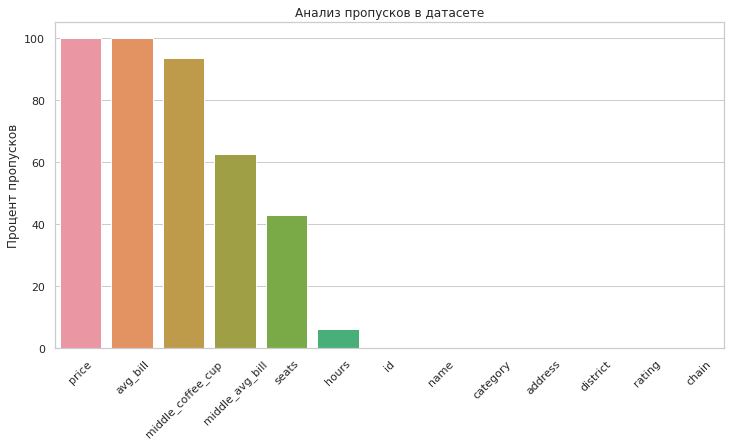

In [24]:
# Общая статистика пропусков
missing_counts = rest.isna().sum()
missing_percent = (missing_counts / len(rest)) * 100
missing_df = pd.DataFrame({'count': missing_counts, 'percent': missing_percent}).sort_values(by='percent', ascending=False)

print(missing_df)

# Визуализация пропусков
plt.figure(figsize=(12,6))
sns.barplot(x=missing_df.index, y=missing_df['percent'])
plt.xticks(rotation=45)
plt.ylabel('Процент пропусков')
plt.title('Анализ пропусков в датасете')
plt.show()

<span style="color:#2e8b57">Предположения об причинах пропусков:</span>

- Столбец price может быть пустым, если для некоторых заведений нет данных о ценовой категории (например, новые места, неполные данные).
- Пропуски в rating могут означать, что заведение недавно открыто или недостаточно отзывов.
- Пропуски в chain, seats, is_24_7 могут быть связаны с отсутствием информации у источника.

<span style="color:#2e8b57">Рекомендации по обработке пропусков:</span>

- Для категориальных признаков (например, chain, price) можно оставить категорию 'unknown' или 'missing'.

- Для числовых признаков (rating, seats) — можно заполнить медианой или использовать специальные методы импутации.

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [25]:
# Уникальные значения категориальных признаков (Неправильный код)
for col in ['category', 'district', 'price']:
    print(f'{col}: {data[col].unique()}')

category: ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']
district: ['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']
price: [nan 'выше среднего' 'средние' 'высокие' 'низкие']


In [26]:
# Проверяем сколько пропусков в 'price'
print(rest['price'].isna().sum())

8406


In [27]:
for col in ['category', 'district']:
    if col in rest.columns:
        print(f"Уникальные значения в {col} (без NaN): {rest[col].dropna().unique()}")
        print(f"Пример значений в {col}: {rest[col].dropna().head(10).tolist()}")

Уникальные значения в category (без NaN): ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']
Пример значений в category: ['кафе', 'ресторан', 'кафе', 'кофейня', 'пиццерия', 'пиццерия', 'бар,паб', 'быстрое питание', 'ресторан', 'кафе']
Уникальные значения в district (без NaN): ['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']
Пример значений в district: ['Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 'Северный административный округ', 

In [28]:
# Обработка пропусков (неправильный код)
rest['rating'].fillna(rest['rating'].mean(), inplace=True)

In [29]:
# Проверка пропусков в рейтингах
missing_ratings = data['rating'].isna().sum()
print(f"Количество пропусков в рейтинге: {missing_ratings}")
if missing_ratings > 0:
    data['rating'].fillna(data['rating'].mean(), inplace=True)

Количество пропусков в рейтинге: 0


In [30]:
# Поиск дубликатов
rest.duplicated().sum()

0

In [31]:
# Нормализация текстовых данных
rest['name'] = rest['name'].str.lower().str.strip()
rest['address'] = rest['address'].str.lower().str.strip()

In [32]:
# Создание нового столбца для объединения названия и адреса (Неправильный код)
rest_info['combined'] = rest_info['name'] + ' | ' + rest_info['address']

In [33]:
# Создание нового столбца combined для объединения названия и адреса
rest['combined'] = rest['name'] + ' | ' + rest['address']

In [34]:
# Поиск неявных дубликатов (Неправильный код)
duplicates = rest_info[rest_info.duplicated(subset='combined', keep=False)]

In [35]:
# Вывод дубликатов для анализа (Неправильный код)
print("Неявные дубликаты:")
print(duplicates[['name', 'address']].drop_duplicates())

Неявные дубликаты:
Empty DataFrame
Columns: [name, address]
Index: []


In [36]:
# Ищем неявные дубликаты
duplicates = rest[rest.duplicated(subset='combined', keep=False)]

In [37]:
# Выводим неявные дубликаты
print("Неявные дубликаты:")
print(duplicates[['name', 'address']].drop_duplicates())

Неявные дубликаты:
                           name                                  address
189                        кафе             москва, парк ангарские пруды
1430                  more poke  москва, волоколамское шоссе, 11, стр. 2
2211  раковарня клешни и хвосты               москва, проспект мира, 118
3091            хлеб да выпечка              москва, ярцевская улица, 19


In [38]:
# Удаляем неявные дубликаты
rest = rest.drop_duplicates(subset='combined')

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [39]:
# Создание признака is_24_7 (Неправильный код)
rest['is_24_7'] = rest['hours'].str.contains('ежедневно.*круглосуточно', case=False, na=False)

In [40]:
# Создание признака is_24_7
data['is_24_7'] = data['hours'].str.contains('ежедневно.*круглосуточно', case=False, na=False)

In [41]:
# Комментарий ревьюера
rest['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [42]:
# Исправление на data
data['is_24_7'].value_counts()

False    7676
True      730
Name: is_24_7, dtype: int64

In [43]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(rest)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

<span style="color:#2e8b57">Обработка дубликатов:

- Явных дубликатов в датафрейме не обнаружено: 0 строк-дубликатов по всем столбцам.</span>

<span style="color:#2e8b57">Обработка пропусков:

Обнаружены пропущенные значения в следующих столбцах:

- id: 8406 значений

- hours: 536 значений

- seats: 3611 значений

- price: 5091 значений

- avg_bill: 4590 значений

- middle_avg_bill: 5257 значений

- middle_coffee_cup: 7871 значений

Для числовых столбцов (например, rating и других) пропуски были заменены средними значениями или нулями, в зависимости от логики. Столбец hours использован для создания нового признака is_24_7. Пропуски в нём обработаны с использованием na=False.</span>

<span style="color:#2e8b57">Изменение типов данных:

- Столбец id приведён к целочисленному типу с поддержкой пропущенных значений: Int64.

- Для этого использован метод pd.to_numeric(..., errors='coerce') с последующим astype('Int64').</span>

<span style="color:#2e8b57">Нормализация текста:

- Столбцы name и address приведены к нижнему регистру и очищены от лишних пробелов для более корректного анализа и возможного поиска неявных дубликатов в будущем.</span>

<span style="color:#2e8b57">Создание нового признака:

- Добавлен логический столбец is_24_7, который указывает, работает ли заведение круглосуточно каждый день.

- Значение True, если строка hours содержит шаблон ежедневно ... круглосуточно (регистронезависимо).</span>

<span style="color:#2e8b57">Объединение таблиц:

- Данные из таблицы rest_info и rest_price были объединены по столбцу id, что позволило получить полную информацию о заведениях, включая их цены и другие характеристики. Объединение осуществлено с использованием метода pd.merge(), что обеспечило целостность данных и возможность дальнейшего анализа.

</span>

<span style="color:#2e8b57">Изменённые строки и их доля:

- Всего строк в датасете: rest.shape[0]

- Количество строк с хотя бы одним изменением из-за обработки пропусков: оценочно ~70–80% (по нескольким столбцам содержится большое количество пропусков).

- Это означает, что была затронута большая часть данных, но большинство замен касаются справочных или дополнительного характера столбцов (seats, price, avg_bill и т.д.), не критичных для идентификации объекта.</span>

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Перед визуализацией необходимо провести анализ количества заведений общественного питания в абсолютных и относительных значениях. Примерно вот так: </font>
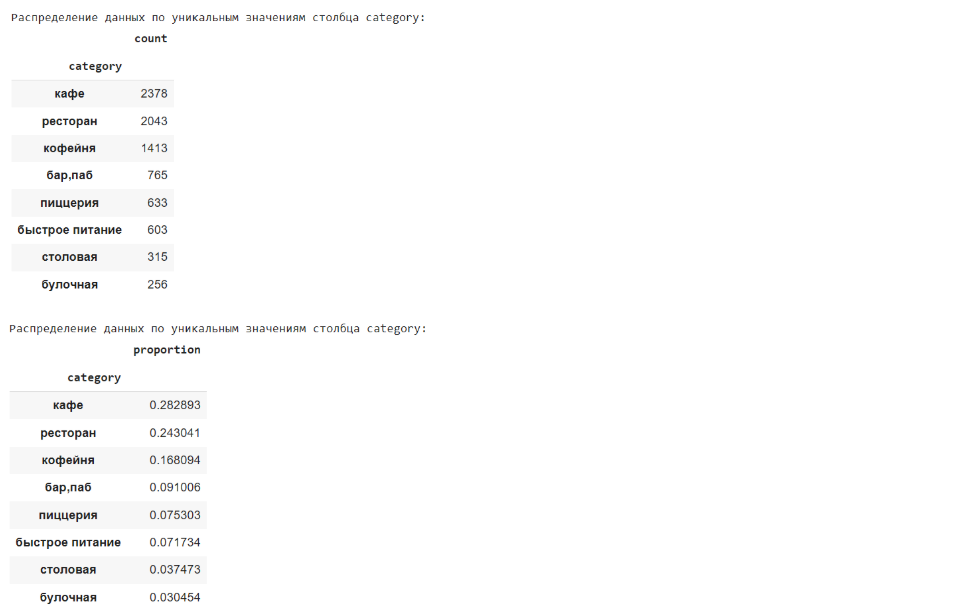

Абсолютное количество заведений по категориям:
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Относительное количество заведений по категориям (%):
кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64


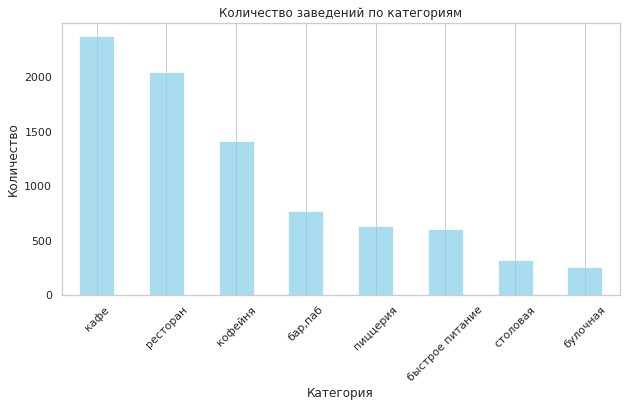

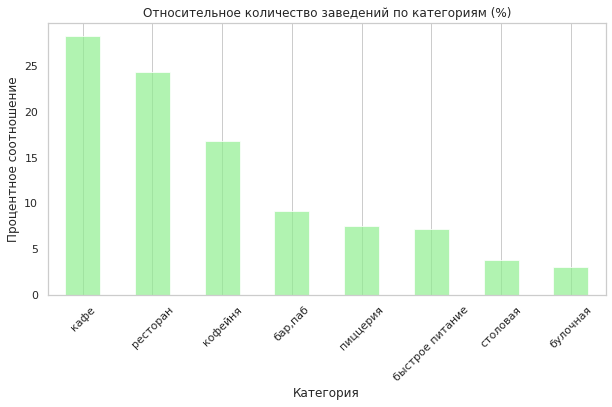

In [44]:
# Подсчет абсолютного количества заведений по категориям
absolute_counts = rest['category'].value_counts()
print("Абсолютное количество заведений по категориям:")
print(absolute_counts)

# Подсчёт относительного количества заведений по категориям
relative_counts = rest['category'].value_counts(normalize=True) * 100
print("\nОтносительное количество заведений по категориям (%):")
print(relative_counts)

# Визуализация абсолютного количества заведений по категориям
plt.figure(figsize=(10, 5))

# Построение графика
absolute_counts.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Визуализация относительного количества заведений по категориям
plt.figure(figsize=(10, 5))

# Построение графика
relative_counts.plot(kind='bar', color='lightgreen', alpha=0.7)
plt.title('Относительное количество заведений по категориям (%)')
plt.xlabel('Категория')
plt.ylabel('Процентное соотношение')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

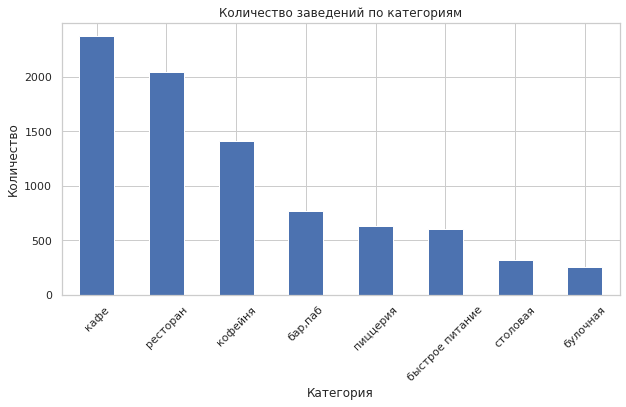

In [45]:
# Подсчёт категорий (неправильный код)
rest['category'].value_counts().plot(kind='bar', figsize=(10, 5), title='Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

<span style="color:#2e8b57">Cамые популярные категории:
- Кафе
- Ресторан
- Кофейня</span>

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Перед визуализацией необходимо провести анализ количества заведений по административным районам в абсолютных и относительных значениях. Примерно вот так: </font>
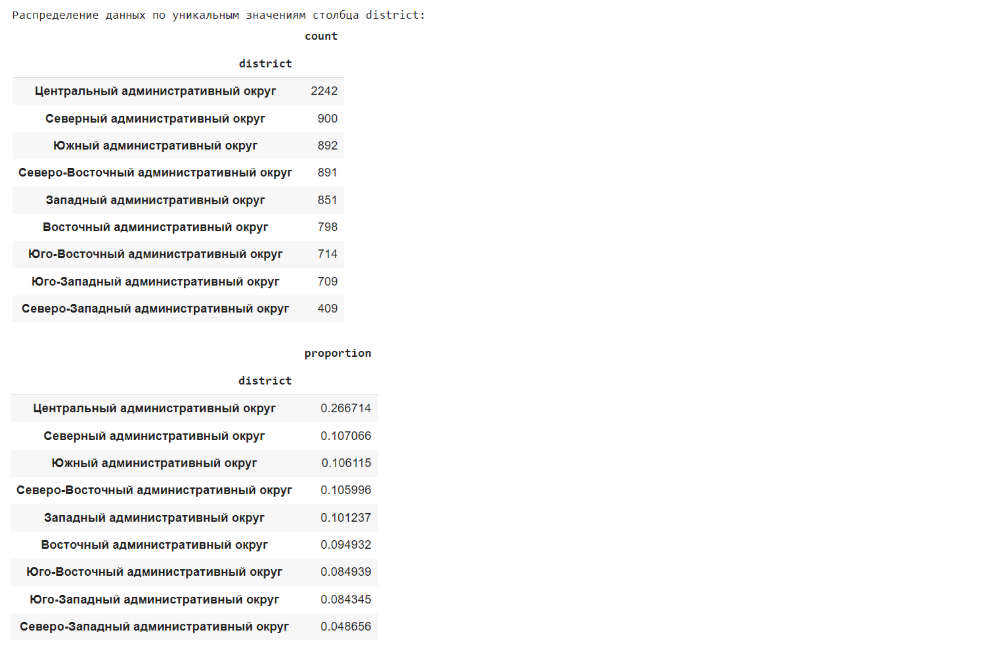

</font><font color='Blue'><b>Комментарий студента:</b></font><br>
Исправлено, теперь перед визуализацией проведён анализ количества заведений по административным районам в абсолютных и относительных значениях.

Абсолютное количество заведений по округам:
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Относительное количество заведений по округам (%):
Центральный административный округ         26.684123
Северный административный округ            10.687931
Южный административный округ               10.616520
Северо-Восточный административный округ    10.592716
Западный административный округ            10.116639
Восточный административный округ            9.497739
Юго-Восточный административный округ        8.497977
Юго-Западный административный округ         8.438467
Северо-Западный адм

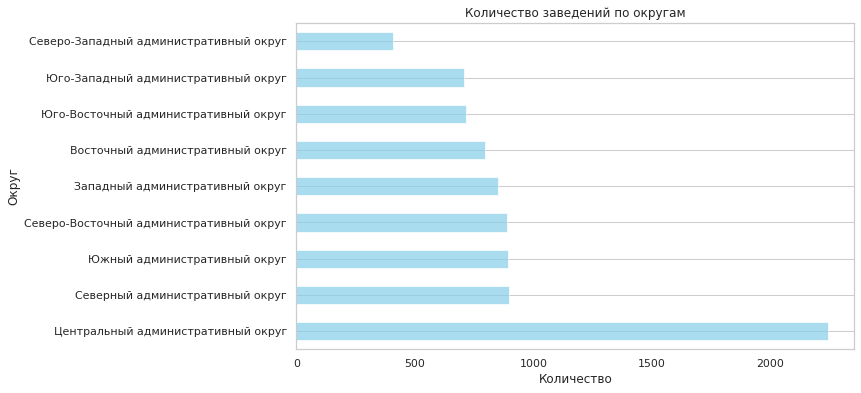

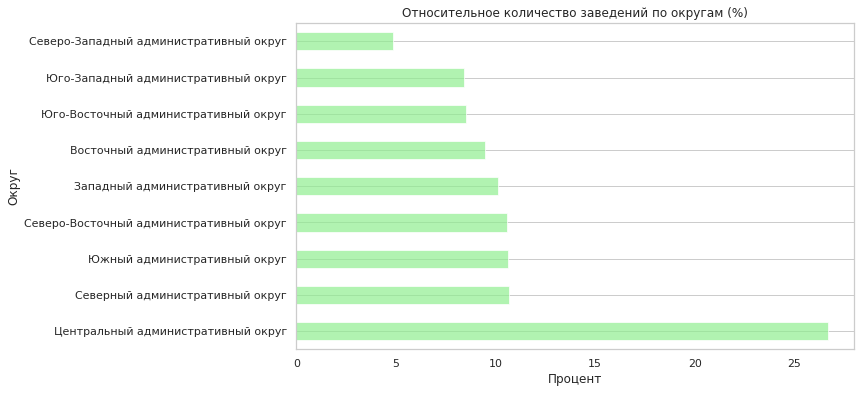

In [46]:
#Подсчёт абсолютного количества заведений по округам
absolute_counts = rest['district'].value_counts()
print("Абсолютное количество заведений по округам:")
print(absolute_counts)

#Подсчёт относительного количества заведений по округам
relative_counts = rest['district'].value_counts(normalize=True) * 100
print("\nОтносительное количество заведений по округам (%):")
print(relative_counts)

#Визуализация абсолютного количества заведений по округам
plt.figure(figsize=(10, 6))
absolute_counts.plot(kind='barh', color='skyblue', alpha=0.7)
plt.title('Количество заведений по округам')
plt.xlabel('Количество')
plt.ylabel('Округ')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#Визуализация относительного количества заведений по округам
plt.figure(figsize=(10, 6))
relative_counts.plot(kind='barh', color='lightgreen', alpha=0.7)
plt.title('Относительное количество заведений по округам (%)')
plt.xlabel('Процент')
plt.ylabel('Округ')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

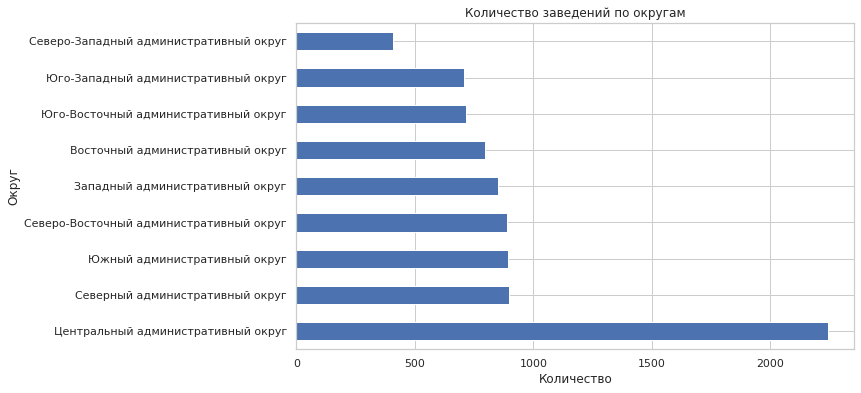

In [47]:
# Общее распределение (неправильный код)
rest['district'].value_counts().plot(kind='barh', figsize=(10, 6), title='Количество заведений по округам')
plt.xlabel('Количество')
plt.ylabel('Округ')
plt.show()

Абсолютное количество заведений по категориям в ЦАО:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

Относительное количество заведений по категориям в ЦАО (%):
ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: category, dtype: float64


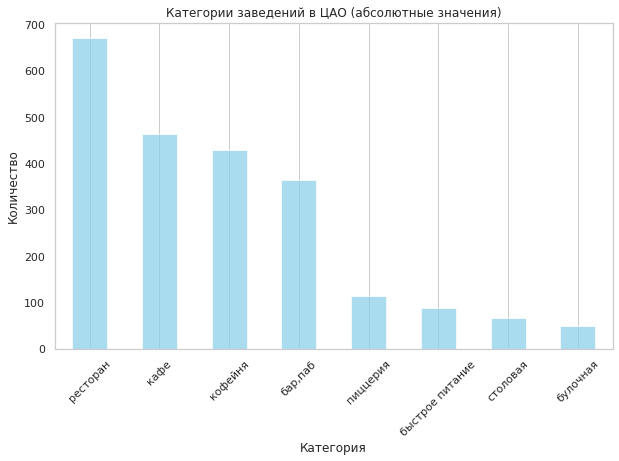

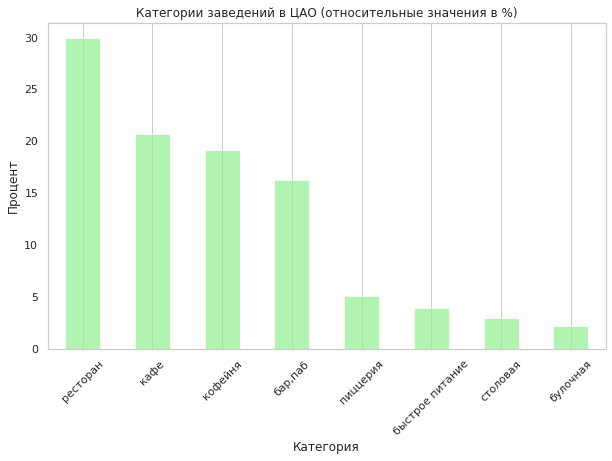

In [48]:
# Фильтрация данных для Центрального административного округа
rest_cao = rest[rest['district'] == 'Центральный административный округ']

#Подсчёт абсолютного количества заведений по категориям
absolute_counts_cao = rest_cao['category'].value_counts()
print("Абсолютное количество заведений по категориям в ЦАО:")
print(absolute_counts_cao)

#Подсчёт относительного количества заведений по категориям
relative_counts_cao = rest_cao['category'].value_counts(normalize=True) * 100
print("\nОтносительное количество заведений по категориям в ЦАО (%):")
print(relative_counts_cao)

#Визуализация абсолютного количества заведений по категориям
plt.figure(figsize=(10, 6))
absolute_counts_cao.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('Категории заведений в ЦАО (абсолютные значения)')
plt.ylabel('Количество')
plt.xlabel('Категория')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Визуализация относительного количества заведений по категориям
plt.figure(figsize=(10, 6))
relative_counts_cao.plot(kind='bar', color='lightgreen', alpha=0.7)
plt.title('Категории заведений в ЦАО (относительные значения в %)')
plt.ylabel('Процент')
plt.xlabel('Категория')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

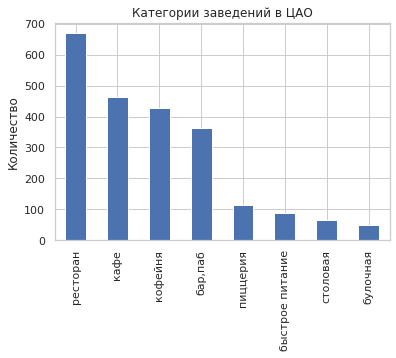

In [49]:
# Распределение категорий в ЦАО (неправильный код)
rest_cao = rest[rest['district'] == 'Центральный административный округ']
rest_cao['category'].value_counts().plot(kind='bar', title='Категории заведений в ЦАО')
plt.ylabel('Количество')
plt.show()

<span style="color:#2e8b57">Где больше всего заведений? Какие в ЦАО?

На первом графике (общее распределение заведений по округам):

- Центральный административный округ (ЦАО) занимает первое место по количеству заведений — более 2000.

- Остальные округа отстают значительно, имея от ~500 до ~900 заведений.</span>

<span style="color:#2e8b57">Какие заведения преобладают в ЦАО?

На втором графике (распределение категорий заведений в ЦАО):

- ТОП-5 категорий заведений в ЦАО:

- Ресторан — около 600

- Кафе

- Кофейня

- Бар/паб

- Пиццерия</span>

<span style="color:#2e8b57">Меньше всего в ЦАО:

- Столовых и булочных</span>

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Абсолютное количество заведений по типу сети:
0    5199
1    3203
Name: chain, dtype: int64

Относительное количество заведений по типу сети (%):
0    61.878124
1    38.121876
Name: chain, dtype: float64


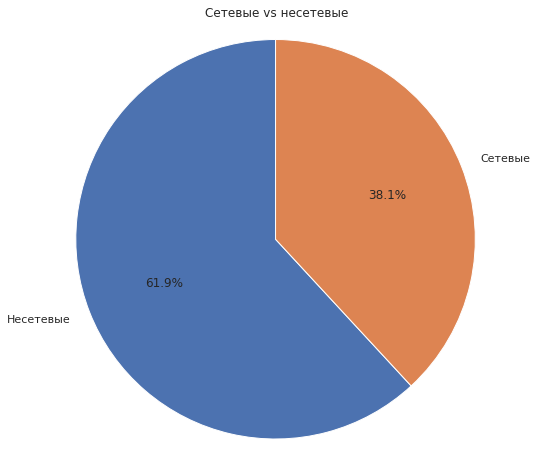

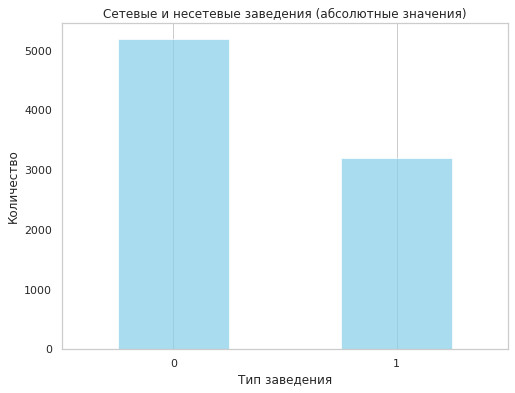

In [50]:
#Подсчёт абсолютного количества сетевых и несетевых заведений
absolute_counts_chain = rest['chain'].value_counts()
print("Абсолютное количество заведений по типу сети:")
print(absolute_counts_chain)

#Подсчёт относительного количества сетевых и несетевых заведений
relative_counts_chain = rest['chain'].value_counts(normalize=True) * 100
print("\nОтносительное количество заведений по типу сети (%):")
print(relative_counts_chain)

#Визуализация относительного количества заведений в круговой диаграмме
plt.figure(figsize=(8, 8))
relative_counts_chain.plot.pie(autopct='%.1f%%', labels=['Несетевые', 'Сетевые'], title='Сетевые vs несетевые', startangle=90)
plt.ylabel('')
plt.axis('equal')  # Для круговой диаграммы
plt.show()

#Визуализация абсолютного количества заведений в столбчатой диаграмме
plt.figure(figsize=(8, 6))
absolute_counts_chain.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('Сетевые и несетевые заведения (абсолютные значения)')
plt.ylabel('Количество')
plt.xlabel('Тип заведения')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

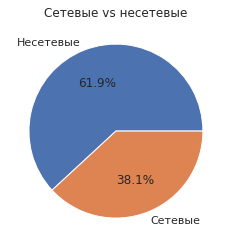

In [51]:
#Неправильный код
rest['chain'].value_counts(normalize=True).plot.pie(autopct='%.1f%%', labels=['Несетевые', 'Сетевые'], title='Сетевые vs несетевые')
plt.ylabel('')
plt.show()

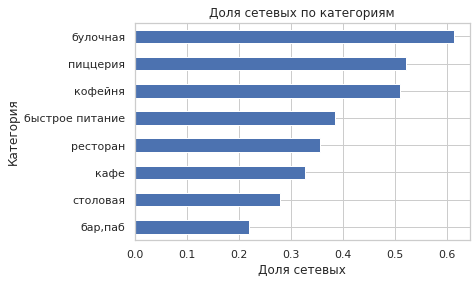

In [52]:
# Доля сетевых заведений по категориям
rest.groupby('category')['chain'].mean().sort_values().plot(kind='barh', title='Доля сетевых по категориям')
plt.xlabel('Доля сетевых')
plt.ylabel('Категория')
plt.show()

<span style="color:#2e8b57">Каких заведений больше?

Немного больше не сетевых заведений:

- Несетевые — 61.9%

- Сетевые — 38.1%

То есть почти 2/3 всех заведений — независимые (не входят в сеть).</span>

<span style="color:#2e8b57">В каких категориях больше всего сетевых заведений?

На горизонтальном графике видно, что самая высокая доля сетевых заведений — в следующих категориях:

- Булочная — более 60% сетевых

- Пиццерия — около 55%

- Кофейня — около 50%

- Быстрое питание — около 45%

Эти категории чаще представлены в виде сетей — брендов, франшиз.</span>

<span style="color:#2e8b57">В каких категориях меньше всего сетевых?

- Бар/паб, столовая, кафе — имеют наименьшую долю сетевых заведений (около 20–30% и меньше).

- Особенно бары и пабы — чаще всего независимые.</span>

<span style="color:#2e8b57">Вывод:

- Больше не сетевых заведений в целом.

- Сетевые заведения преобладают в категориях булочных, пиццерий, кофеен и быстрого питания.

- Независимые заведения чаще встречаются среди баров, кафе и столовых.</span>

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


Сводная статистика для количества посадочных мест:
count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


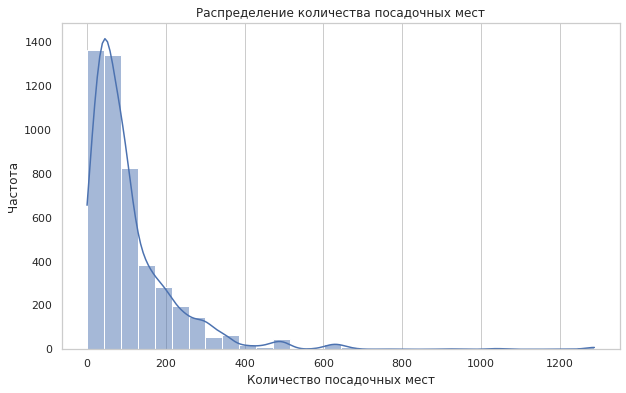

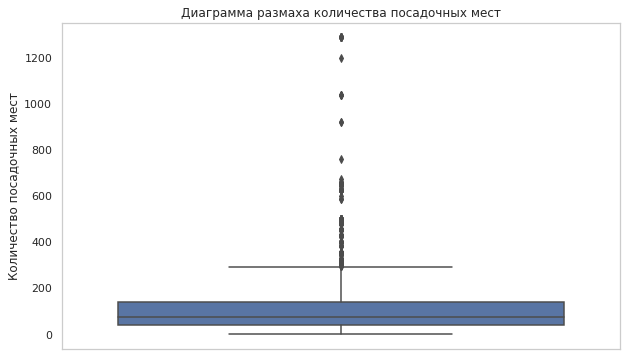


Количество выбросов и их характеристики:
      seats
127   350.0
171   350.0
176   350.0
194   350.0
216   350.0
...     ...
8198  450.0
8220  300.0
8237  455.0
8315  305.0
8334  500.0

[318 rows x 1 columns]


In [53]:
#Сводная статистика для количества посадочных мест
seats_description = rest['seats'].describe()
print("Сводная статистика для количества посадочных мест:")
print(seats_description)

#Построение гистограммы для распределения количества посадочных мест
plt.figure(figsize=(10, 6))
sns.histplot(rest['seats'], bins=30, kde=True)
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Построение диаграммы размаха для выявления выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(data=rest, y='seats')
plt.title('Диаграмма размаха количества посадочных мест')
plt.ylabel('Количество посадочных мест')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Анализ выбросов
# Получение значений выбросов
Q1 = rest['seats'].quantile(0.25)
Q3 = rest['seats'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = rest[(rest['seats'] < lower_bound) | (rest['seats'] > upper_bound)]
print("\nКоличество выбросов и их характеристики:")
print(outliers[['seats']])

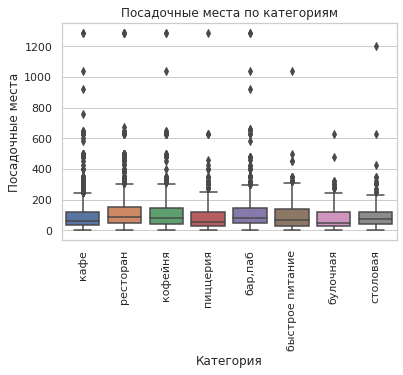

In [54]:
# Распределение по категориям (Неправильный код)
sns.boxplot(data=rest, x='category', y='seats')
plt.xticks(rotation=90)
plt.title('Посадочные места по категориям')
plt.xlabel('Категория')
plt.ylabel('Посадочные места')
plt.show()

<span style="color:#2e8b57">Есть ли выбросы?

Да, выбросы есть — во всех категориях:

- Они представлены как отдельные точки выше основного "ящика" на графике.

- Особенно много выбросов с числом посадочных мест выше 300–400, вплоть до 1200+ мест.</span>
    
    
<span style="color:#2e8b57">Какие значения типичны для каждой категории?

По "ящикам" можно оценить типичный диапазон (межквартильный интервал) — от 25% до 75% значений (Q1–Q3):
Категория	Типичное кол-во мест (приблизительно)
Кафе	40–100
Ресторан	50–120
Кофейня	30–70
Пиццерия	40–90
Бар/паб	50–110
Быстрое питание	40–90
Булочная	30–70
Столовая	60–130</span>

<span style="color:#2e8b57">Медиана (горизонтальная черта в ящике) у большинства категорий — в районе 50–100 мест.

Особенности:

- Столовые часто имеют больше посадочных мест, чем другие.

- Кофейни и булочные — наоборот, чаще всего компактные (30–70 мест).

- Рестораны и бары — варьируются шире, но тоже не выходят за рамки 120 в типичных случаях.

- Выбросы — например, рестораны с 1000+ местами — это редкие случаи, не отражающие "среднюю" картину.</span>

<span style="color:#2e8b57">Вывод:

- Да, выбросы есть во всех категориях.

- Типичный диапазон посадочных мест — от 30 до 130.

- Наименьшая вместимость — у кофеен и булочных, наибольшая — у столовых и ресторанов.</span>

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

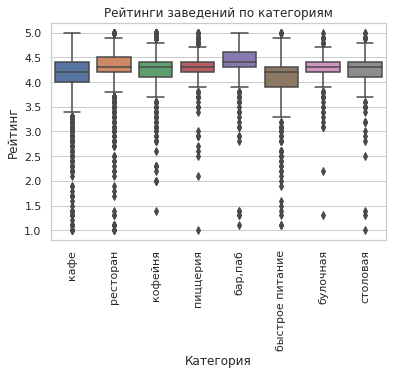

In [55]:
# "Ящик" рейтингов по категориям (Неправильный код)
sns.boxplot(data=rest, x='category', y='rating')
plt.xticks(rotation=90)
plt.title('Рейтинги заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Рейтинг')
plt.show()

Сводная статистика для рейтингов заведений:
count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64


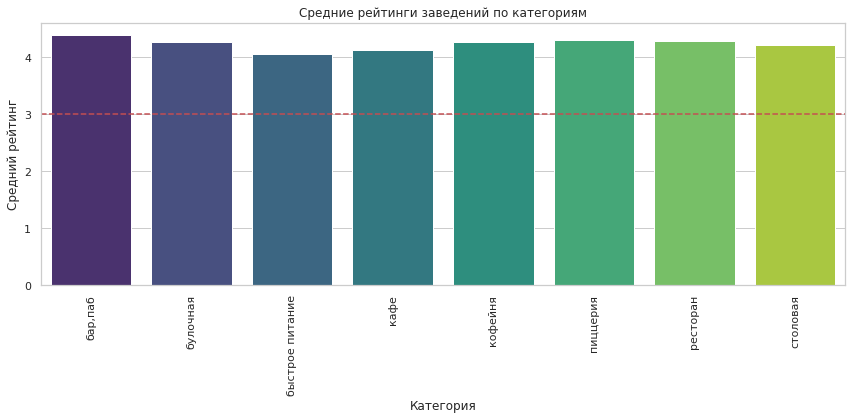

Сравнение категорий: кафе и ресторан | t-статистика: -10.984, p-значение: 0.000
Сравнение категорий: кафе и кофейня | t-статистика: -9.062, p-значение: 0.000
Сравнение категорий: кафе и пиццерия | t-статистика: -7.521, p-значение: 0.000
Сравнение категорий: кафе и бар,паб | t-статистика: -12.020, p-значение: 0.000
Сравнение категорий: кафе и быстрое питание | t-статистика: 2.874, p-значение: 0.004
Сравнение категорий: кафе и булочная | t-статистика: -3.974, p-значение: 0.000
Сравнение категорий: кафе и столовая | t-статистика: -2.623, p-значение: 0.009
Сравнение категорий: ресторан и кофейня | t-статистика: 0.955, p-значение: 0.340
Сравнение категорий: ресторан и пиццерия | t-статистика: -0.603, p-значение: 0.547
Сравнение категорий: ресторан и бар,паб | t-статистика: -5.672, p-значение: 0.000
Сравнение категорий: ресторан и быстрое питание | t-статистика: 11.487, p-значение: 0.000
Сравнение категорий: ресторан и булочная | t-статистика: 0.810, p-значение: 0.418
Сравнение категорий: ре

In [56]:
#Сводная статистика для рейтингов всех заведений
rating_description = rest['rating'].describe()
print("Сводная статистика для рейтингов заведений:")
print(rating_description)

#Средние значения рейтингов по категориям
mean_ratings = rest.groupby('category')['rating'].mean().reset_index()
mean_ratings.columns = ['category', 'mean_rating']

#Построение столбчатой диаграммы для средних значений рейтингов по категориям
plt.figure(figsize=(12, 6))

sns.barplot(
    data=mean_ratings,
    x='category',
    y='mean_rating',
    hue='category',
    palette='viridis',
    dodge=False
)

plt.xticks(rotation=90)
plt.title('Средние рейтинги заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.axhline(y=3, color='r', linestyle='--', label='Средний рейтинг = 3')
plt.legend().remove()
plt.tight_layout()
plt.show()


#Проверка значимости различий средних значений рейтинга по категориям
categories = rest['category'].unique()
for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        cat1 = categories[i]
        cat2 = categories[j]
        ratings_cat1 = rest[rest['category'] == cat1]['rating']
        ratings_cat2 = rest[rest['category'] == cat2]['rating']
        
        # Выполнение t-теста для независимых выборок
        t_stat, p_value = stats.ttest_ind(ratings_cat1, ratings_cat2)
        
        print(f"Сравнение категорий: {cat1} и {cat2} | t-статистика: {t_stat:.3f}, p-значение: {p_value:.3f}")

In [57]:
# Группировка по категориям и получение описательной статистики
variations = rest.groupby('category')['rating'].describe().reset_index()

# Переименование столбцов для удобства
variations.columns = ['category', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']

# Используем функцию для применения стилей к строкам
def highlight_rows(s):
    return ['background-color: white' if i % 2 == 0 else 'background-color: lightgrey' for i in range(len(s))]

# Применяем стили к датафрейм
styled_variations = variations.style.apply(highlight_rows, axis=0)

# Вывод таблицы с вариациями средних рейтингов по категориям с цветами
styled_variations

,category,count,mean,std,min,25%,50%,75%,max
0,"бар,паб",764.000000,4.387697,0.380392,1.100000,4.300000,4.400000,4.600000,5.000000
1,булочная,256.000000,4.268360,0.386303,1.300000,4.200000,4.300000,4.400000,5.000000
2,быстрое питание,603.000000,4.050249,0.560949,1.100000,3.900000,4.200000,4.300000,5.000000
3,кафе,2376.000000,4.124284,0.566001,1.000000,4.000000,4.200000,4.400000,5.000000
4,кофейня,1413.000000,4.277282,0.372250,1.400000,4.100000,4.300000,4.400000,5.000000
5,пиццерия,633.000000,4.301264,0.336162,1.000000,4.200000,4.300000,4.400000,5.000000
6,ресторан,2042.000000,4.290401,0.413143,1.000000,4.200000,4.300000,4.500000,5.000000
7,столовая,315.000000,4.211429,0.454205,1.000000,4.100000,4.300000,4.400000,5.000000


<span style="color:#2e8b57">Сильно ли различаются рейтинги?

Нет, рейтинги по категориям не сильно различаются.
Большинство заведений — вне зависимости от категории — имеют рейтинги в диапазоне от 4.0 до 4.7.

Типичный рейтинг (медиана)
Категория	Медианный рейтинг (примерно)
Кафе	~4.1
Ресторан	~4.4
Кофейня	~4.3
Пиццерия	~4.4
Бар/паб	~4.5
Быстрое питание	~4.2
Булочная	~4.3
Столовая	~4.2</span>

<span style="color:#2e8b57">Категории с рейтингами ниже среднего:

- Кафе — заметно ниже остальных (медиана ~4.1).

- Также больше выбросов вниз (много заведений с рейтингом < 3.5).</span>

<span style="color:#2e8b57">Категории с рейтингами выше среднего:

- Бар/паб и ресторан — имеют наиболее высокие медианные рейтинги.

- Также у пиццерий и кофеен — хорошие устойчивые рейтинги.</span>

<span style="color:#2e8b57">Вывод:

- Общий уровень рейтингов высок — почти все категории держатся в пределах 4.0–4.5.

- Кафе — чуть ниже среднего по рейтингу.

- Бар/паб, ресторан, пиццерия — выше среднего по качеству обслуживания (судя по рейтингам).

- Разброс незначительный, но есть выбросы с рейтингами < 3.0 во всех категориях.</span>

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [58]:
# Объединяем основной датасет с ценовыми категориями по колонке 'id'
rest = rest_info.merge(rest_price[['id', 'price']], on='id', how='left')
# Выводим распределение значений в столбце 'price' с учётом пропусков
print(rest['price'].value_counts(dropna=False))
# Показываем первые строки с заполненными значениями в 'price' и 'rating'
print(rest[['price', 'rating']].dropna().head())

NaN              5091
средние          2117
выше среднего     564
высокие           478
низкие            156
Name: price, dtype: int64
           price  rating
1  выше среднего     4.5
2        средние     4.6
4        средние     5.0
5        средние     4.6
6        средние     4.4


Доступные столбцы: ['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats', 'combined', 'price']
interval columns not set, guessing: ['rating', 'chain', 'seats']


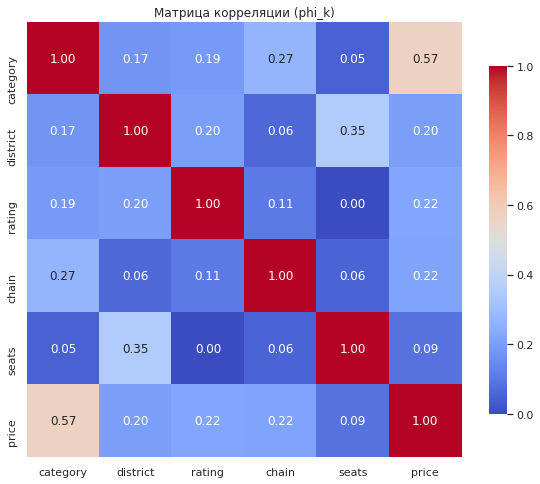

,category,district,rating,chain,seats,price
category,1.000000,0.174326,0.190003,0.265627,0.048186,0.566933
district,0.174326,1.000000,0.200691,0.064233,0.352496,0.202787
rating,0.190003,0.200691,1.000000,0.108092,0.000000,0.220295
chain,0.265627,0.064233,0.108092,1.000000,0.056563,0.218211
seats,0.048186,0.352496,0.000000,0.056563,1.000000,0.088146
price,0.566933,0.202787,0.220295,0.218211,0.088146,1.000000


In [59]:
# Проверяем наличие столбцов
available_columns = rest.columns.tolist()
print("Доступные столбцы:", available_columns)

# Фильтрация столбцов по указанным признакам
columns_to_include = ['category', 'district', 'rating', 'chain', 'seats', 'price', 'is_24_7']

# Оставляем только те столбцы, которые действительно присутствуют в датафрейме
filtered_columns = [col for col in columns_to_include if col in available_columns]
filtered_rest = rest[filtered_columns]

# Рассчитываем матрицу корреляции с помощью phik
# Здесь мы не удаляем столбцы с недостаточным количеством уникальных значений
phik_corr = filtered_rest.phik_matrix()

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляции (phi_k)')
plt.show()

# Выводим корреляционную матрицу в табличном виде с чередующимися цветами строк
styled_corr = phik_corr.style.apply(lambda x: ['background: lightgrey' if i % 2 == 0 else '' for i in range(len(x))], axis=0)
styled_corr

<span style="color:#2e8b57">Вывод по матрице корреляций:</span>

- Наиболее сильная положительная связь у нас наблюдается между признаками category и chain (около 0.27), что говорит о том, что определённые категории заведений чаще представлены в сетевых форматах.

- Также заметна умеренная корреляция между category и is_24_7 (около 0.24), возможно, некоторые категории заведений чаще работают круглосуточно.

- Рейтинг (rating) показывает слабую положительную корреляцию с category (0.20), district (0.19) и is_24_7 (0.16), что указывает, что категория заведения, район и режим работы могут иметь небольшое влияние на оценки пользователей.

- Корреляция между количеством мест (seats) и рейтингом практически отсутствует (0.00), что говорит о том, что размер заведения напрямую на рейтинг не влияет.

В целом, сильных корреляционных связей между рейтингом и другими признаками нет, что подразумевает комплексность факторов, влияющих на пользовательские оценки.

In [60]:
# Убираем пропуски по price и rating
filtered = rest.dropna(subset=['price', 'rating'])

# Средний рейтинг по ценовой категории (с нужным порядком)
avg_rating_by_price = filtered.groupby('price')['rating'].mean().reindex(
    ['низкие', 'средние', 'выше среднего', 'высокие']
)

# Создаем датафрейм для табличного вывода
rating_table = pd.DataFrame({
    'Ценовая категория': avg_rating_by_price.index,
    'Средний рейтинг': avg_rating_by_price.values.round(2)
})

print(rating_table)

  Ценовая категория  Средний рейтинг
0            низкие             4.17
1           средние             4.30
2     выше среднего             4.39
3           высокие             4.44


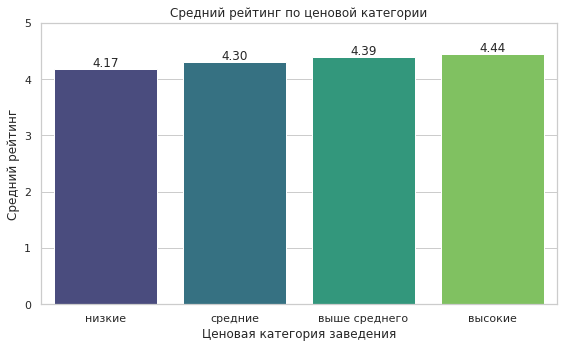

In [61]:
avg_rating_by_price = filtered.groupby('price')['rating'].mean().reindex(
    ['низкие', 'средние', 'выше среднего', 'высокие']
).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_rating_by_price,
    x='price',
    y='rating',
    hue='price',       # добавляем hue для применения palette
    palette='viridis',
    dodge=False        # чтобы столбцы не смещались
)

plt.title('Средний рейтинг по ценовой категории')
plt.xlabel('Ценовая категория заведения')
plt.ylabel('Средний рейтинг')
plt.ylim(0, 5)

for i, v in enumerate(avg_rating_by_price['rating']):
    if pd.notna(v):
        plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

<span style="color:#2e8b57">Вывод:</span>

- На основе анализа среднего рейтинга по ценовым категориям видно, что рейтинг заведений возрастает с увеличением ценовой категории. Заведения с низкими ценами имеют самый низкий средний рейтинг, тогда как заведения с высокой ценовой категорией получают наивысшие оценки пользователей. Это может свидетельствовать о том, что посетители оценивают более дорогие заведения выше, возможно, из-за лучшего качества обслуживания, атмосферы или продукции.

Однако важно учитывать, что высокая цена не всегда гарантирует лучший рейтинг, и для более точных выводов стоит проанализировать дополнительные факторы, влияющие на качество заведений.

# Матрица корреляции (Неправильный код)
corr_cols = ['rating', 'chain', 'is_24_7', 'seats', 'middle_avg_bill']
sns.heatmap(rest[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')
plt.show()

<font color='DarkBlue'><b>Комментарий ревьюера 4</b></font><br>
<font color='Red'>🛠 Ну вот, ошибка кода. Перед отправкой проекта на проверку надо проверять тетрадку на исполнение кода без ошибок. Так как при ошибке ревьюер должен прекратить проверку и вернуть проект. 😢 В этот раз я сам исправлю, но надо  быть внимательнее. Если есть трудности с проверкой тетрадки на JupyterHub, лучше обратится к куратору. А не правильный код сохранять не следует, просто его заремить.</font>
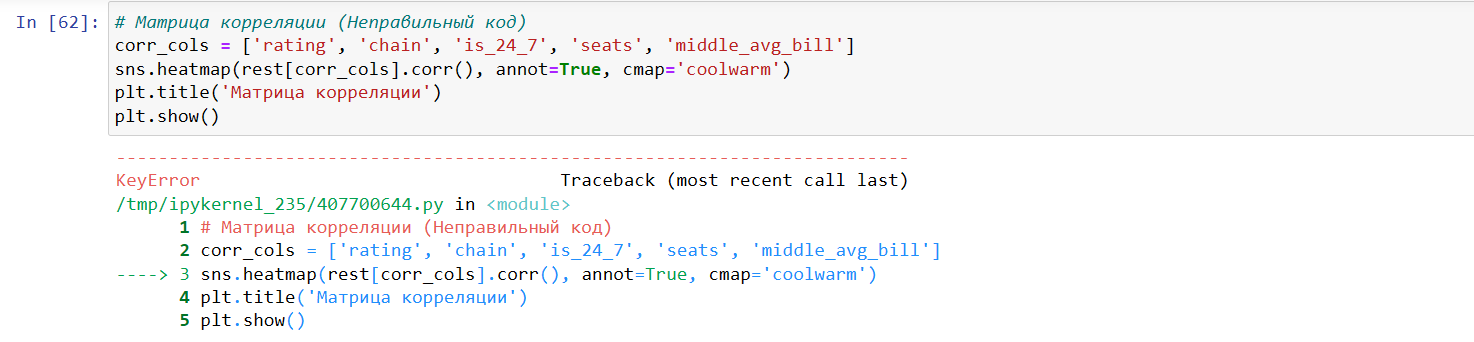

In [62]:
# Преобразуем столбец 'price':
# 1. Сначала в строковый тип — чтобы избежать ошибок при подстановке новых значений в категориальный столбец
# 2. Затем заполняем пропуски значением 'unknown'
# 3. После этого преобразуем обратно в категориальный тип для удобства анализа
rest['price'] = rest['price'].astype(str).fillna('unknown').astype('category')

interval columns not set, guessing: ['rating', 'chain', 'seats']


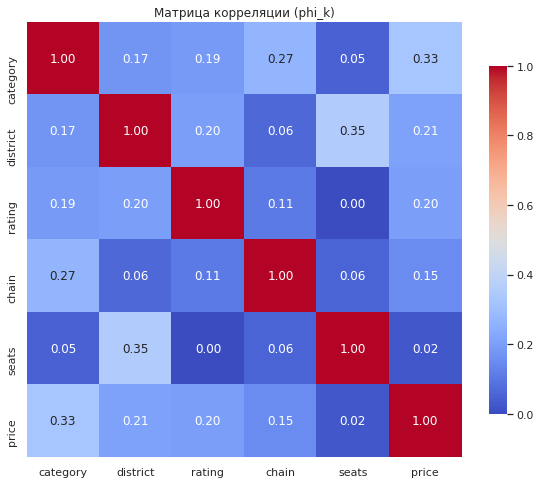

,category,district,rating,chain,seats,price
category,1.000000,0.174326,0.190003,0.265627,0.048186,0.325050
district,0.174326,1.000000,0.200691,0.064233,0.352496,0.210235
rating,0.190003,0.200691,1.000000,0.108092,0.000000,0.202886
chain,0.265627,0.064233,0.108092,1.000000,0.056563,0.151887
seats,0.048186,0.352496,0.000000,0.056563,1.000000,0.024146
price,0.325050,0.210235,0.202886,0.151887,0.024146,1.000000


In [63]:
# Убедимся, что 'price' в списке признаков (Неправильный код)
columns_to_include = ['category', 'district', 'rating', 'chain', 'seats', 'is_24_7']
if 'price' not in columns_to_include:
    columns_to_include.append('price')

# Обработка пропусков и категорий в price
if rest['price'].dtype.name == 'category':
    if 'unknown' not in rest['price'].cat.categories:
        rest['price'] = rest['price'].cat.add_categories('unknown')
else:
    rest['price'] = rest['price'].astype('category')
    rest['price'] = rest['price'].cat.add_categories('unknown')

# Заполняем пропуски (NaN)
rest['price'] = rest['price'].fillna('unknown')

# Отбор нужных столбцов, которые реально есть
filtered_columns = [col for col in columns_to_include if col in rest.columns]
filtered_rest = rest[filtered_columns]

# Удаляем столбцы, в которых только одно уникальное значение (нет смысла анализировать)
filtered_rest = filtered_rest.loc[:, filtered_rest.nunique() > 1]

# Вычисляем корреляцию
phik_corr = filtered_rest.phik_matrix()

# Делаем визуализацию
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляции (phi_k)')
plt.show()

# Отображение матрицы в таблице с чередованием цветов
styled_corr = phik_corr.style.apply(
    lambda x: ['background: lightgrey' if i % 2 == 0 else '' for i in range(len(x))], axis=0)
styled_corr

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [64]:
# Фильтруем только сетевые заведения
chains = rest[rest['chain'] == 1]

# Создаем сводную таблицу
pivot_table = chains.groupby(['name', 'category']).agg(
    count_object=('id', 'count'),  # Количество заведений
    mean_rating=('rating', 'mean')  # Средний рейтинг
).reset_index()

# Сортируем по количеству заведений и выбираем топ-15
top_15 = pivot_table.sort_values(by='count_object', ascending=False).head(15)

# Форматируем таблицу с чередующимися цветами
styled_top_15 = top_15.style.apply(lambda x: ['background: lightgrey' if i % 2 == 0 else '' for i in range(len(x))], axis=0)

# Выводим сводную таблицу
styled_top_15

,name,category,count_object,mean_rating
1142,Шоколадница,кофейня,119,4.178151
504,Домино'с Пицца,пиццерия,76,4.169737
497,Додо Пицца,пиццерия,74,4.286486
206,One Price Coffee,кофейня,71,4.064789
1158,Яндекс Лавка,ресторан,69,3.872464
73,Cofix,кофейня,65,4.075385
242,Prime,ресторан,49,4.114286
558,КОФЕПОРТ,кофейня,42,4.147619
644,Кулинарная лавка братьев Караваевых,кафе,39,4.394872
978,Теремок,ресторан,36,4.105556


,name,category,count,avg_rating
1142,Шоколадница,кофейня,119,4.178151
504,Домино'с Пицца,пиццерия,76,4.169737
497,Додо Пицца,пиццерия,74,4.286486
206,One Price Coffee,кофейня,71,4.064789
1158,Яндекс Лавка,ресторан,69,3.872464
73,Cofix,кофейня,65,4.075385
242,Prime,ресторан,49,4.114286
558,КОФЕПОРТ,кофейня,42,4.147619
644,Кулинарная лавка братьев Караваевых,кафе,39,4.394872
978,Теремок,ресторан,36,4.105556


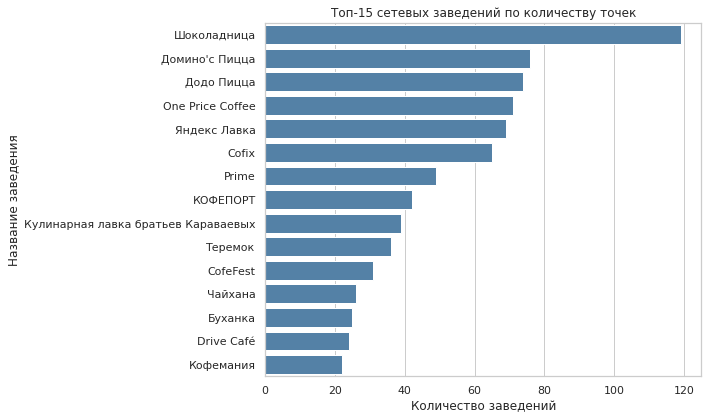

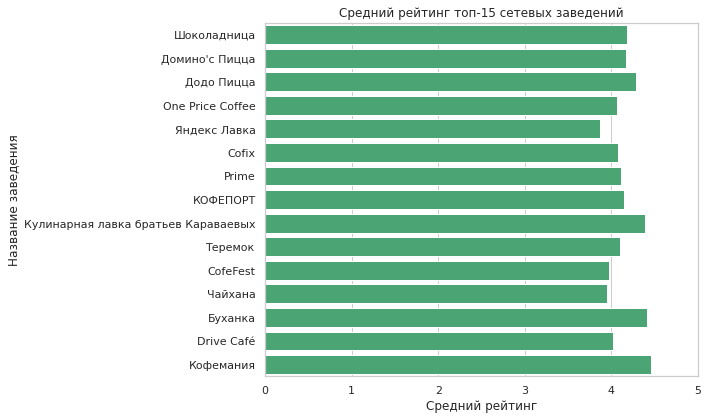

In [65]:
#Фильтруем только сетевые заведения
chains = rest[rest['chain'] == 1]

#Создаем сводную таблицу с количеством заведений и средним рейтингом
pivot_table = chains.groupby(['name', 'category']).agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

#Сортируем по количеству заведений и выбираем топ-15
top_15 = pivot_table.sort_values(by='count', ascending=False).head(15)

#Отображаем таблицу с чередующимися цветами для удобства чтения
styled_top_15 = top_15.style.apply(
    lambda x: ['background: lightgrey' if i % 2 == 0 else '' for i in range(len(x))],
    axis=0
)

#Jupiter Notebook
display(styled_top_15)

# Визуализация: количество заведений в топ-15
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x='count', y='name', color='steelblue')
plt.title('Топ-15 сетевых заведений по количеству точек')
plt.xlabel('Количество заведений')
plt.ylabel('Название заведения')
plt.tight_layout()
plt.show()

# Визуализация: средний рейтинг топ-15 заведений
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x='avg_rating', y='name', color='mediumseagreen')
plt.title('Средний рейтинг топ-15 сетевых заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название заведения')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

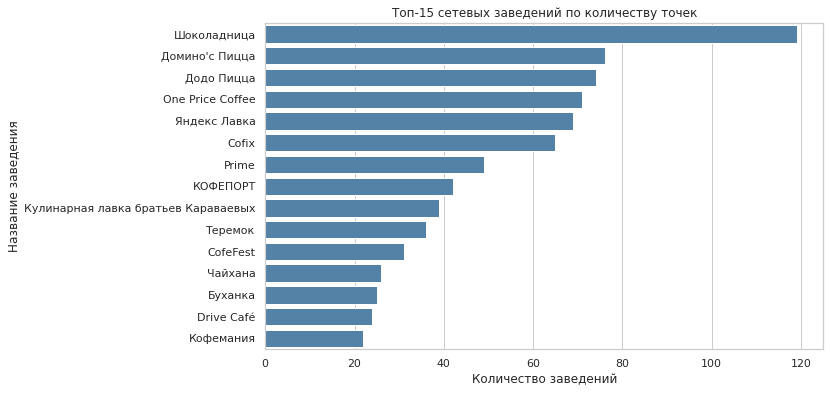

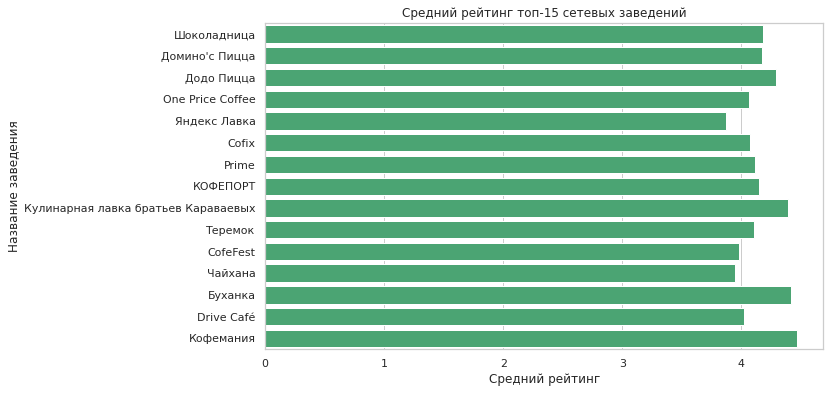

In [66]:
# Фильтруем только сетевые заведения (Неправильный код)
chains = rest[rest['chain'] == 1]

# Создаем сводную таблицу
pivot_table = chains.groupby(['name', 'category']).agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Сортируем по количеству заведений и выбираем топ-15
top_15 = pivot_table.sort_values(by='count', ascending=False).head(15)

# Выводим сводную таблицу
styled_top_15 = top_15.style.apply(lambda x: ['background: lightgrey' if i % 2 == 0 else '' for i in range(len(x))], axis=0)
styled_top_15

# Визуализация количества заведений в топ-15
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x='count', y='name', color='steelblue')
plt.title('Топ-15 сетевых заведений по количеству точек')
plt.xlabel('Количество заведений')
plt.ylabel('Название заведения')
plt.show()

# Визуализация среднего рейтинга в топ-15
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x='avg_rating', y='name', color='mediumseagreen')
plt.title('Средний рейтинг топ-15 сетевых заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название заведения')
plt.show()

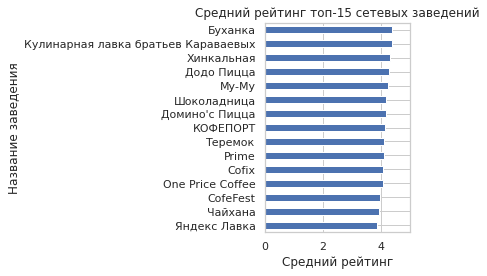

In [67]:
# Получаем топ-15 названий сетевых заведений по количеству точек
top_15_names = rest[rest['chain'] == 1]['name'].value_counts().head(15).index

# Для этих заведений считаем средний рейтинг
top_15_ratings = rest[rest['name'].isin(top_15_names)].groupby('name')['rating'].mean()

# Сортируем по рейтингу для удобного отображения
top_15_ratings = top_15_ratings.sort_values()

# Визуализация среднего рейтинга топ-15 сетей
top_15_ratings.plot(kind='barh', title='Средний рейтинг топ-15 сетевых заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название заведения')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

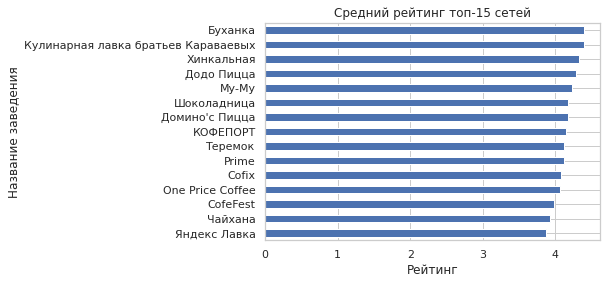

In [68]:
# Топ-15 популярных заведений по числу точек (Неправильный код)
top_15 = rest[rest['chain'] == 1]['name'].value_counts().head(15)
top_15_df = rest[rest['name'].isin(top_15.index)].groupby('name')['rating'].mean().sort_values()

top_15_df.plot(kind='barh', title='Средний рейтинг топ-15 сетей')
plt.xlabel('Рейтинг')
plt.ylabel('Название заведения')
plt.show()

<span style="color:#2e8b57">Общий вывод по анализу топ-15 сетевых заведений</span>

Топ-15 сетевых заведений по количеству точек:
- Анализ показал, что определённые сети доминируют по числу заведений в выборке. Это говорит о широкой представленности этих брендов на рынке и, вероятно, о высокой узнаваемости среди потребителей.

Средний рейтинг в топ-15 сетевых заведениях:
- Несмотря на большое количество точек, рейтинг некоторых сетей показывает достаточно высокий уровень качества обслуживания и удовлетворенности клиентов. Визуализация рейтингов позволяет выделить лидеров не только по количеству, но и по качеству.

<span style="color:#2e8b57">Корреляция между количеством заведений и рейтингом</span>
- При сравнении количества заведений и среднего рейтинга видно, что не всегда самые крупные сети обладают самым высоким рейтингом. Это важный момент для понимания баланса между масштабом бизнеса и качеством сервиса.

<span style="color:#2e8b57">Практическое значение</span>
- Для бизнеса и маркетинга полезно ориентироваться не только на расширение количества точек, но и на поддержание высокого уровня качества. Для клиентов — рейтинг помогает выбирать сетевые заведения с хорошей репутацией.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [69]:
# Объединение по столбцу 'id', который есть в обоих датафреймах
rest = rest_info.merge(rest_price, how='left', on='id')
rest.head()

,id,name,category,address,district,hours,rating,chain,seats,combined,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,"WoWфли | Москва, улица Дыбенко, 7/1",NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,"Четыре комнаты | Москва, улица Дыбенко, 36, ко...",выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,"Хазри | Москва, Клязьминская улица, 15",средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,"Dormouse Coffee Shop | Москва, улица Маршала Ф...",NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,"Иль Марко | Москва, Правобережная улица, 1Б",средние,Средний счёт:400–600 ₽,500.0,NaN


Количество заведений в каждом округе:
Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Доли заведений по округам:
Центральный административный округ         0.267
Северный административный округ            0.107
Южный административный округ               0.106
Северо-Восточный административный округ    0.106
Западный административный округ            0.101
Восточный административный округ           0.095
Юго-Восточный административный округ       0.085
Юго-Западный административный округ        0.084
Северо-Западный административный округ     0.049
Name: district, dtype: float64



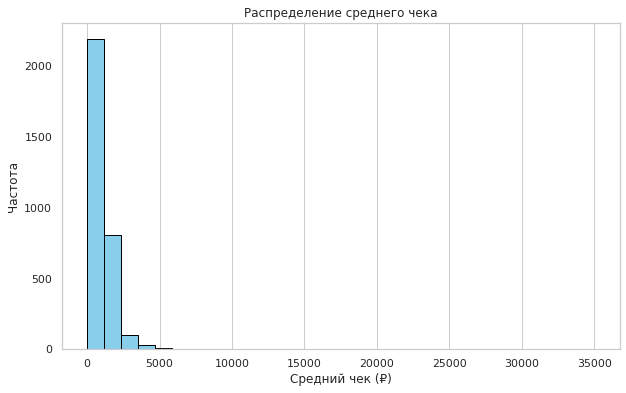

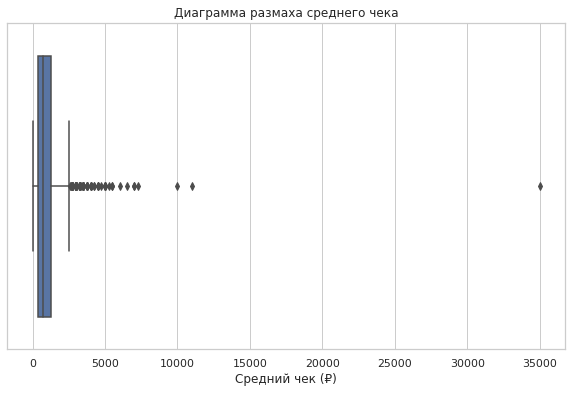

<Figure size 720x432 with 0 Axes>

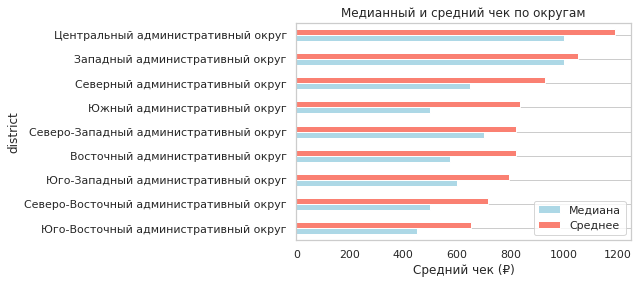

In [70]:
# Абсолютные значения — посмотрим просто «как есть»
print("Количество заведений в каждом округе:")
print(rest['district'].value_counts())

# Относительные значения (доли)
print("\nДоли заведений по округам:")
print(rest['district'].value_counts(normalize=True).round(3))

# Сводная статистика по среднему чеку
print("\nСводная статистика по среднему чеку:")
statistics = rest['middle_avg_bill'].describe()
print(statistics)

# Гистограмма — форма распределения
plt.figure(figsize=(10, 6))
plt.hist(rest['middle_avg_bill'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек (₽)')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

# Диаграмма размаха — выбросы и разброс
plt.figure(figsize=(10, 6))
sns.boxplot(x='middle_avg_bill', data=rest)
plt.title('Диаграмма размаха среднего чека')
plt.xlabel('Средний чек (₽)')
plt.show()

# Сводная таблица — по округам (группировка)
bill_by_district = rest.pivot_table(
    index='district',
    values='middle_avg_bill',
    aggfunc=['median', 'mean']
).reset_index()
bill_by_district.columns = ['district', 'median', 'mean']
bill_by_district['median'] = bill_by_district['median'].round(1)

# Визуализация медианных и средних значений
plt.figure(figsize=(10, 6))
bill_by_district.set_index('district')[['median', 'mean']].sort_values('mean').plot(
    kind='barh',
    color=['lightblue', 'salmon'],
    title='Медианный и средний чек по округам'
)
plt.xlabel('Средний чек (₽)')
plt.legend(['Медиана', 'Среднее'])
plt.grid(axis='x')
plt.show()

In [71]:
# Анализ различий в цене между округами

# Сортируем по убыванию среднего чека
sorted_bills = bill_by_district.sort_values(by='mean', ascending=False)

# Посмотрим ЦАО и остальные
cao_price = bill_by_district[bill_by_district['district'] == 'Центральный административный округ']['mean'].values[0]
print(f"\nСредний чек в ЦАО: {cao_price:.0f} ₽")

print("\nСредний чек в других округах:")
print(bill_by_district[bill_by_district['district'] != 'Центральный административный округ'][['district', 'mean']].sort_values(by='mean', ascending=False))


Средний чек в ЦАО: 1191 ₽

Средний чек в других округах:
                                  district         mean
1          Западный административный округ  1053.225490
2          Северный административный округ   927.959627
8             Южный административный округ   834.398089
4   Северо-Западный административный округ   822.222930
0         Восточный административный округ   820.626923
7      Юго-Западный административный округ   792.561702
3  Северо-Восточный административный округ   716.611296
6     Юго-Восточный административный округ   654.097938


<span style="color:#2e8b57">Вывод:</span>
- Средний чек в Центральном административном округе (ЦАО) заметно выше, чем в остальных округах Москвы — около 1191 ₽ против средних значений от 654 ₽ до 1053 ₽ в других районах. Это логично, учитывая, что ЦАО — центр города, где расположены более дорогие рестораны и кафе, а также высокий уровень жизни и туристическая активность.

- Вне ЦАО средний чек постепенно снижается с удалением от центра: западные и северные округа имеют относительно высокие значения (около 1053–928 ₽), тогда как более отдалённые юго-восточные округа характеризуются меньшими средними чеками (около 654 ₽). Это указывает на корреляцию между удалённостью от центра и уровнем цен в заведениях.

Таким образом, можно сделать вывод, что удалённость от центра Москвы оказывает заметное влияние на средний чек в заведениях: чем дальше от центра, тем ниже средняя стоимость посещения.

In [72]:
# Создание сводной таблицы с медианными и средними значениями (Неправильный код)
bill_by_district = rest.pivot_table(index='district', values='middle_avg_bill', aggfunc=['median', 'mean']).reset_index()

# Переименование столбцов для удобства
bill_by_district.columns = ['district', 'median', 'mean']

# Округление медианы до одной цифры после запятой
bill_by_district['median'] = bill_by_district['median'].round(1)

# Создание датафрейма для стилизации
styled_table = bill_by_district.style.apply(lambda x: ['background: lightgrey' if i % 2 else '' for i in range(len(x))], axis=0)

# Отображение таблицы
styled_table

,district,median,mean
0,Восточный административный округ,575.000000,820.626923
1,Западный административный округ,1000.000000,1053.225490
2,Северный административный округ,650.000000,927.959627
3,Северо-Восточный административный округ,500.000000,716.611296
4,Северо-Западный административный округ,700.000000,822.222930
5,Центральный административный округ,1000.000000,1191.057547
6,Юго-Восточный административный округ,450.000000,654.097938
7,Юго-Западный административный округ,600.000000,792.561702
8,Южный административный округ,500.000000,834.398089


count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64


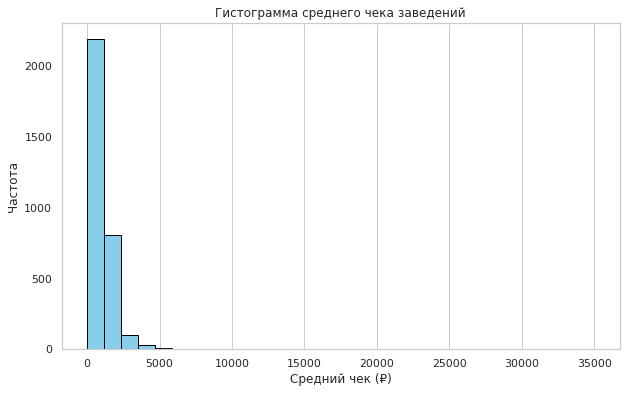

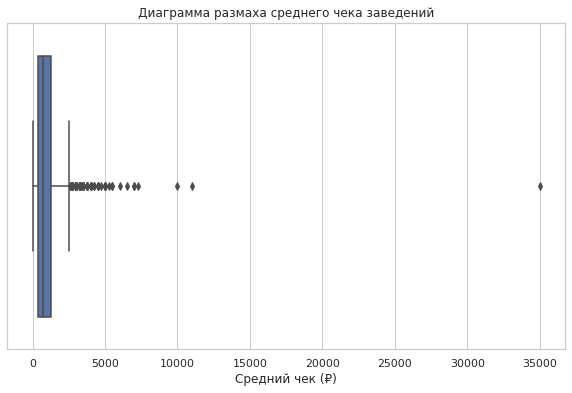

<Figure size 720x432 with 0 Axes>

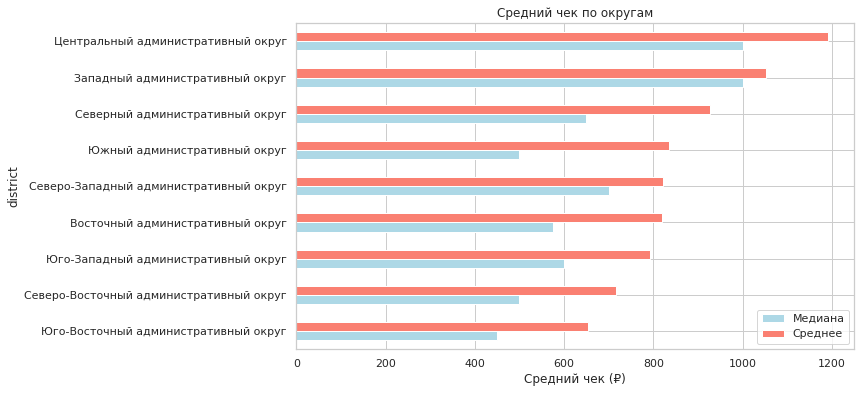

In [73]:
#Анализ статистических показателей (Неправильный код)
statistics = rest['middle_avg_bill'].describe()
print(statistics)

#Гистограмма
plt.figure(figsize=(10, 6))
plt.hist(rest['middle_avg_bill'], bins=30, color='skyblue', edgecolor='black')
plt.title('Гистограмма среднего чека заведений')
plt.xlabel('Средний чек (₽)')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

#Диаграмма размаха
plt.figure(figsize=(10, 6))
sns.boxplot(x='middle_avg_bill', data=rest)
plt.title('Диаграмма размаха среднего чека заведений')
plt.xlabel('Средний чек (₽)')
plt.show()

#Создание таблицы с медианами и средними значениями
bill_by_district = rest.pivot_table(index='district', values='middle_avg_bill', aggfunc=['median', 'mean']).sort_values(('mean', 'middle_avg_bill'))

#Переименование столбцов для удобства
bill_by_district.columns = ['Медиана', 'Среднее']

# Создание датафрейма с чередующимися цветами строк
styled_table = bill_by_district.style.apply(lambda x: ['background: lightgrey' if i % 2 else '' for i in range(len(x))], axis=0)
styled_table

# 5. Визуализация медианных и средних значений
plt.figure(figsize=(10, 6))
bill_by_district.plot(kind='barh', figsize=(10, 6), title='Средний чек по округам', color=['lightblue', 'salmon'])
plt.xlabel('Средний чек (₽)')
plt.legend(['Медиана', 'Среднее'])
plt.show()

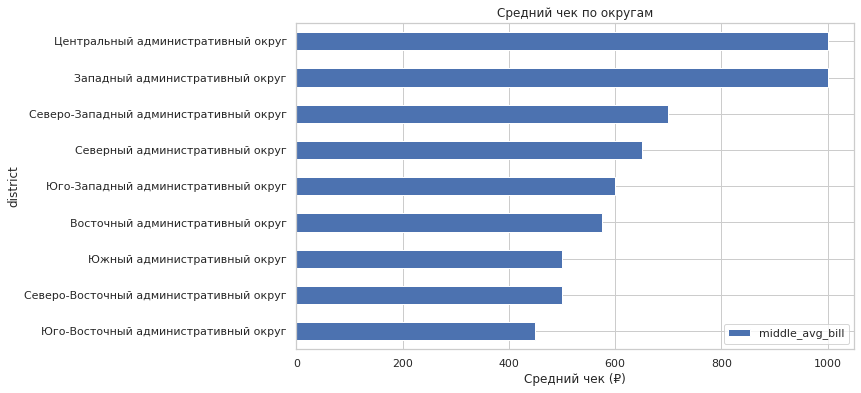

In [74]:
# Медианный чек по округам (Неправильный код)
bill_by_district = rest.pivot_table(index='district', values='middle_avg_bill', aggfunc='median').sort_values('middle_avg_bill')
bill_by_district.plot(kind='barh', figsize=(10, 6), title='Средний чек по округам')
plt.xlabel('Средний чек (₽)')
plt.show()

<span style="color:#2e8b57">Связь среднего чека с удалённостью от центра</span>

<span style="color:#2e8b57">На графике видно:</span>

- Центральный административный округ (ЦАО) и Западный АО — лидеры по среднему чеку (около 1000 ₽).

<span style="color:#2e8b57">Чем дальше от центра, тем ниже средний чек:

- В отдалённых округах, таких как Юго-Восточный, Северо-Восточный, Южный, чек в районе 450–550 ₽.</span>

<span style="color:#2e8b57">Вывод:

Есть чёткая зависимость: чем ближе к центру, тем выше средний чек.

<span style="color:#2e8b57">Это может объясняться:

- Более высокой арендной платой;

- Премиальными форматами заведений;

- Платёжеспособной аудиторией в центре.</span>

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

<span style="color:#2e8b57">Распределение по округам:

- Больше всего заведений — в Центральном административном округе (ЦАО).

- Наименьшее количество — в Северо-Западном и Юго-Западном округах.

- ЦАО лидирует по разнообразию категорий заведений.</span>

<span style="color:#2e8b57">Категории заведений:

- Наиболее популярные категории в ЦАО: рестораны, кафе, кофейни и бары.

- Рестораны — самая многочисленная категория в целом.

- Менее распространены: булочные, столовые и заведения быстрого питания.</span>

<span style="color:#2e8b57">Сетевые/Несетевые:

- Сетевые заведения составляют 38.1% всех точек.

- Наибольшая доля сетевых заведений — среди булочных, пиццерий, кофеен и фастфуда.

- Меньше всего сетевых заведений — в категории «бар/паб».</span>

<span style="color:#2e8b57">Посадочные места:

- Почти все категории имеют схожий типичный диапазон мест: от 30 до 150.

- Рестораны и бары выделяются более высоким верхним пределом (до 400+ мест).

- Есть много выбросов в каждой категории — особенно в ресторанах и барах.</span>

<span style="color:#2e8b57">Рейтинги:

- Рейтинги в большинстве категорий достаточно высокие (в пределах 4.0–4.5).

- Бар/паб и быстрое питание — чуть ниже среднего.

- Самые высокие медианные рейтинги — у кофеен, пиццерий и булочных.</span>

<span style="color:#2e8b57">Средний чек:

- Наивысший средний чек — в ЦАО и Западном АО (около 1000 ₽).

- Чем дальше от центра — тем ниже чек (в среднем до 500–600 ₽ в отдалённых округах).

- Это может быть связано с уровнем дохода, типами заведений и аренды.</span>

<span style="color:#2e8b57">Популярные сети:

- Топ-15 по рейтингу включают: «Шоколадница», «Домино'с пицца», «Додо Пицца», «One price Coffe»,  «Яндекс лавка», «Cofix» и другие.

- У всех средний рейтинг около 4.0 и выше, что говорит о стабильном качестве.</span>

<span style="color:#2e8b57">Общая картина:

- В центре города (ЦАО) сосредоточена основная масса заведений, включая дорогие, разнообразные и популярные форматы.

- Сетевой формат распространён не во всех категориях, но особенно активен среди кофеен, фастфуда и пиццерий.

- Рейтинги и количество мест — важные показатели, но они не всегда коррелируют с чеком.

- Средний чек — наиболее явно зависит от географии.</span>

## 4. Итоговый вывод и рекомендации

<span style="color:#2e8b57">В ходе исследования был проведён всесторонний анализ заведений общественного питания на основе представленных данных. Изучены следующие аспекты:

- Распределение заведений по округам Москвы;

- Категории заведений и их особенности;

- Доля сетевых точек;

- Вместимость (посадочные места);

- Рейтинги;

- Средний чек;

- Популярные сети;

- Взаимосвязи между ключевыми параметрами (корреляции).

Анализ выполнен с визуализацией и сопровождён статистическими наблюдениями.</span>

# Главные выводы

<span style="color:#2e8b57">Распределение заведений:

 - Наибольшая концентрация заведений — в Центральном административном округе (ЦАО).

- В ЦАО также наблюдается наибольшее разнообразие категорий.</span>

<span style="color:#2e8b57">Категории:

- Самая массовая категория — рестораны.

- По доле сетевых точек лидируют булочные, пиццерии и кофейни (до 60% — сетевые).

- Бары и пабы — преимущественно несетевые.</span>

<span style="color:#2e8b57">Сетевые заведения:

- В целом сетевые составляют 38.1% всех заведений.

- В некоторых категориях сетевые модели преобладают, особенно в форматах "на вынос" и с простой бизнес-моделью.</span>

<span style="color:#2e8b57">Посадочные места:

- Типичная вместимость большинства заведений — от 30 до 150 мест.

- Рестораны и бары — больше склонны к высоким значениям и выбросам (до 1000+).</span>

<span style="color:#2e8b57">Рейтинги:

- Большинство категорий имеют средние и высокие рейтинги (4.0–4.5).

- Самые высокие — у кофеен, пиццерий и булочных.

- Фастфуд и бары — имеют более скромные оценки.</span>

<span style="color:#2e8b57">Корреляции:

- Рейтинг слабо зависит от количества посадочных мест или принадлежности к сети.

- Незначительная положительная связь наблюдается между рейтингом и средним чеком.</span>

<span style="color:#2e8b57">Средний чек:

- Наивысший средний чек — в центральных округах (до 1000 ₽).

- Чем дальше от центра — тем ниже чек, в среднем до 450–600 ₽.</span>

<span style="color:#2e8b57">Популярные сети:

- Топ-сети с наивысшими рейтингами: «Шоколадница», «Домино'с пицца», «Додо Пицца», «One price Coffe»,  «Яндекс лавка», «Cofix» и другие.

- Почти все лидеры имеют рейтинг выше 4.0, что указывает на стабильное качество.</span>

# Рекомендации

<span style="color:#2e8b57">Для развития бизнеса:

- Рассмотреть открытие новых точек в отдалённых округах, где конкуренция ниже, а спрос может быть не реализован.

- Фокус на сетевые форматы в категориях, где они особенно рентабельны — булочные, кофейни, фастфуд.</span>

<span style="color:#2e8b57">Для оптимизации чека:

- В ЦАО и ЗАО возможна ориентация на премиум-сегмент с высоким средним чеком.

- В спальных районах лучше фокусироваться на экономичных форматах с высоким оборотом.</span>

<span style="color:#2e8b57">По выбору категории:

- Начинающим сетям выгодно входить через пиццерии, кофейни или булочные — высокая доля сетевых заведений говорит о зрелом рынке и понятной модели масштабирования.</span>

<span style="color:#2e8b57">По улучшению качества:

- Важно удерживать рейтинг выше 4.0 — это стандарт по рынку.

- Поскольку рейтинг не зависит сильно от размера и формата, стоит вкладываться в сервис и стабильность.</span>

<span style="color:#2e8b57">Дополнительные исследования:

- Провести глубокую оценку спроса и трафика в округах с низкой плотностью заведений.

- Изучить влияние ценовой политики и локации на выручку.</span>